# Load Data

sklearn's `load_diabetes` is a regression dataset, so we threshold the target at its median to get a balanced binary classification, then take an HIV-shaped 23 / 68 subset.

In [1]:
from sklearn.datasets import load_diabetes
import numpy as np

data = load_diabetes()
X = data.data
y_cont = data.target
y = (y_cont > np.median(y_cont)).astype(int)

print("Full dataset shape:", X.shape)
print("Class 0 / 1 counts (full):", (y == 0).sum(), (y == 1).sum())


Full dataset shape: (442, 10)
Class 0 / 1 counts (full): 221 221


In [2]:
def make_hiv_like_subset(X, y, n0=23, n1=68, seed=42):
    rng = np.random.default_rng(seed)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    if len(idx0) < n0 or len(idx1) < n1:
        raise ValueError(f"Not enough samples: class 0 has {len(idx0)}, class 1 has {len(idx1)}")
    take0 = rng.choice(idx0, size=n0, replace=False)
    take1 = rng.choice(idx1, size=n1, replace=False)
    keep_idx = np.concatenate([take0, take1])
    rng.shuffle(keep_idx)
    return X[keep_idx], y[keep_idx], keep_idx

X, y, idx_small = make_hiv_like_subset(X, y, n0=23, n1=68, seed=42)
print("Subset shape:", X.shape)
print("Class 0 count:", (y == 0).sum())
print("Class 1 count:", (y == 1).sum())


Subset shape: (91, 10)
Class 0 count: 23
Class 1 count: 68


## Standardize

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


## Convert to tensors

In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64)


# CVAE

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CVAE(nn.Module):
    def __init__(self, x_dim: int, c_dim: int, z_dim: int, hidden: int):
        super().__init__()
        self.x_dim = x_dim
        self.c_dim = c_dim
        self.z_dim = z_dim

        self.enc = nn.Sequential(
            nn.Linear(x_dim + c_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.mu     = nn.Linear(hidden, z_dim)
        self.logvar = nn.Linear(hidden, z_dim)

        self.dec = nn.Sequential(
            nn.Linear(z_dim + c_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, x_dim),
        )

    def encode(self, x, c):
        h = self.enc(torch.cat([x, c], dim=1))
        return self.mu(h), self.logvar(h)

    @staticmethod
    def reparameterize(mu, logvar):
        eps = torch.randn_like(mu)
        sigma = torch.exp(0.5 * logvar)
        return mu + sigma * eps

    def decode(self, z, c):
        return self.dec(torch.cat([z, c], dim=1))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, c)
        return x_hat, mu, logvar


In [6]:
def elbo_loss(x, x_hat, mu, logvar, beta=1.0):
    recon = ((x - x_hat) ** 2).sum(dim=1).mean()
    kl    = (-0.5 * (1 + logvar - mu**2 - logvar.exp()).sum(dim=1)).mean()
    return recon + beta * kl


In [7]:
from dataclasses import dataclass

@dataclass
class Config:
    seed: int = 42
    z_dim: int = 16
    hidden: int = 128
    beta: float = 0.5
    epochs: int = 200
    batch_size: int = 64
    lr: float = 1e-3


# Train CVAE and sample

In [8]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

cfg = Config()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=cfg.seed, stratify=y
)

scaler = StandardScaler()
scaler.fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

device = "cuda" if torch.cuda.is_available() else "cpu"

X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=cfg.batch_size,
    shuffle=True,
)

model = CVAE(x_dim=X_tr_s.shape[1], c_dim=2, z_dim=cfg.z_dim, hidden=cfg.hidden).to(device)
opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

for epoch in range(cfg.epochs):
    model.train()
    total = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        cb = F.one_hot(yb, num_classes=2).float()

        x_hat, mu, logvar = model(xb, cb)
        loss = elbo_loss(xb, x_hat, mu, logvar, beta=cfg.beta)

        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item() * xb.size(0)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | loss={total/len(X_tr_t):.4f}")


Epoch  50 | loss=6.3116
Epoch 100 | loss=5.4770
Epoch 150 | loss=4.8270
Epoch 200 | loss=4.5056


In [9]:
@torch.no_grad()
def sample_scaled(model, n, y_label, device):
    model.eval()
    z = torch.randn(n, model.z_dim, device=device)
    c = F.one_hot(torch.full((n,), y_label, dtype=torch.long, device=device), num_classes=2).float()
    return model.decode(z, c).cpu().numpy()

n0 = int((y == 0).sum())
n1 = int((y == 1).sum())

X_syn0 = sample_scaled(model, n0, y_label=0, device=device)
X_syn1 = sample_scaled(model, n1, y_label=1, device=device)
X_syn  = np.vstack([X_syn0, X_syn1])
y_syn  = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])

X_scaled = scaler.transform(X)
print("real:", X_scaled.shape, "syn:", X_syn.shape)


real: (91, 10) syn: (91, 10)


# Single-split distinguishability

In [10]:
def distinguishability_auc_proper(X_real, X_syn, seed=0):
    X_all = np.vstack([X_real, X_syn])
    s_all = np.concatenate([np.zeros(len(X_real), dtype=int),
                            np.ones(len(X_syn), dtype=int)])
    Xtr, Xte, str_, ste = train_test_split(
        X_all, s_all, test_size=0.2, random_state=seed, stratify=s_all
    )
    rf = RandomForestClassifier(n_estimators=500, random_state=seed)
    rf.fit(Xtr, str_)
    p = rf.predict_proba(Xte)[:, 1]
    return roc_auc_score(ste, p)

auc = distinguishability_auc_proper(X_te_s, np.vstack([
    sample_scaled(model, int((y_te == 0).sum()), 0, device),
    sample_scaled(model, int((y_te == 1).sum()), 1, device),
]), seed=0)
print("Distinguishability AUC:", auc)
print("Separability:", max(auc, 1 - auc))


Distinguishability AUC: 1.0
Separability: 1.0


# Stratified holdout (HIV protocol)

In [11]:
def strat_samp(idx0, idx1, n0, n1, rng):
    a = rng.choice(idx0, size=n0, replace=False)
    b = rng.choice(idx1, size=n1, replace=False)
    return np.concatenate([a, b])


def one_stochastic_experiment(
    X_real, y_real,
    X_syn,  y_syn,
    holdout0=3, holdout1=12,
    train0=20,  train1=20,
    seed=0,
):
    rng = np.random.default_rng(seed)

    real0 = np.where(y_real == 0)[0]
    real1 = np.where(y_real == 1)[0]
    syn0  = np.where(y_syn  == 0)[0]
    syn1  = np.where(y_syn  == 1)[0]

    test_real_idx = strat_samp(real0, real1, holdout0, holdout1, rng)
    test_syn_idx  = strat_samp(syn0,  syn1,  holdout0, holdout1, rng)

    rem_real = np.setdiff1d(np.arange(len(X_real)), test_real_idx)
    rem_syn  = np.setdiff1d(np.arange(len(X_syn)),  test_syn_idx)

    rem_real0 = rem_real[y_real[rem_real] == 0]
    rem_real1 = rem_real[y_real[rem_real] == 1]
    rem_syn0  = rem_syn[y_syn[rem_syn] == 0]
    rem_syn1  = rem_syn[y_syn[rem_syn] == 1]

    train_real_idx = strat_samp(rem_real0, rem_real1, train0, train1, rng)
    train_syn_idx  = strat_samp(rem_syn0,  rem_syn1,  train0, train1, rng)

    X_train = np.vstack([X_real[train_real_idx], X_syn[train_syn_idx]])
    s_train = np.concatenate([np.zeros(len(train_real_idx), dtype=int),
                              np.ones(len(train_syn_idx), dtype=int)])
    X_test  = np.vstack([X_real[test_real_idx],  X_syn[test_syn_idx]])
    s_test  = np.concatenate([np.zeros(len(test_real_idx), dtype=int),
                              np.ones(len(test_syn_idx), dtype=int)])

    rf = RandomForestClassifier(n_estimators=500, random_state=seed)
    rf.fit(X_train, s_train)
    p = rf.predict_proba(X_test)[:, 1]
    return roc_auc_score(s_test, p)


def run_many_trials(X_real, y_real, X_syn, y_syn, trials=200):
    aucs = []
    for t in range(trials):
        aucs.append(one_stochastic_experiment(
            X_real, y_real, X_syn, y_syn,
            holdout0=3, holdout1=12,
            train0=20, train1=20,
            seed=t,
        ))
    return np.array(aucs)

aucs = run_many_trials(X_scaled, y, X_syn, y_syn, trials=200)
print("mean AUC:", aucs.mean())
print("std AUC :", aucs.std())
print("min/max :", aucs.min(), aucs.max())


mean AUC: 0.9797777777777779
std AUC : 0.028095076674273956
min/max : 0.8777777777777779 1.0


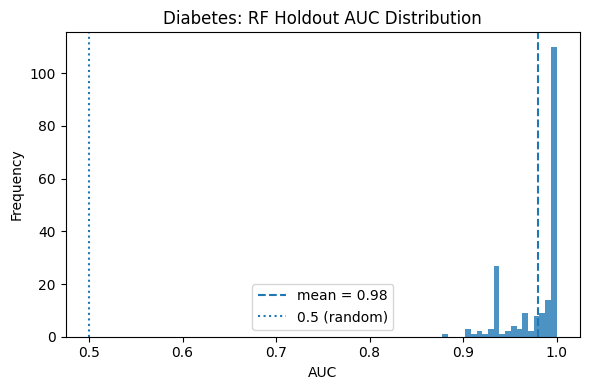

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(aucs, bins=20, alpha=0.8)
plt.axvline(aucs.mean(), linestyle="--", label=f"mean = {aucs.mean():.2f}")
plt.axvline(0.5, linestyle=":", label="0.5 (random)")
plt.title("Diabetes: RF Holdout AUC Distribution")
plt.xlabel("AUC")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


# RF-driven ablation

Same protocol as the HIV and breast cancer notebooks: fit RF on real-vs-syn, sort `feature_importances_`, drop top-k, re-probe.

In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

feature_names = list(data.feature_names)

real_X = pd.DataFrame(X_scaled, columns=feature_names)
real_y = np.asarray(y).astype(int)

syn_X = pd.DataFrame(X_syn, columns=feature_names)
syn_y = np.asarray(y_syn).astype(int)

n_neg = int(min((real_y == 0).sum(), (syn_y == 0).sum()))
n_pos = int(min((real_y == 1).sum(), (syn_y == 1).sum()))
print(f"real: {real_X.shape}  syn: {syn_X.shape}  n_neg={n_neg}  n_pos={n_pos}")

rng_ab = np.random.default_rng(42)

def strat_samp_db(neg_i, pos_i, n_neg, n_pos):
    a = rng_ab.choice(neg_i, size=n_neg, replace=False)
    b = rng_ab.choice(pos_i, size=n_pos, replace=False)
    return np.concatenate([a, b])

def rf_auc_probe_stratified(real_X, real_y, syn_X, syn_y, n_neg, n_pos, seed=42):
    real_y = np.asarray(real_y).astype(int)
    syn_y  = np.asarray(syn_y).astype(int)

    real_neg_i = np.where(real_y == 0)[0]
    real_pos_i = np.where(real_y == 1)[0]
    syn_neg_i  = np.where(syn_y == 0)[0]
    syn_pos_i  = np.where(syn_y == 1)[0]

    real_idx = strat_samp_db(real_neg_i, real_pos_i, n_neg, n_pos)
    syn_idx  = strat_samp_db(syn_neg_i,  syn_pos_i,  n_neg, n_pos)

    Xp = pd.concat([real_X.iloc[real_idx], syn_X.iloc[syn_idx]], axis=0).to_numpy()
    sp = np.r_[np.zeros(len(real_idx), dtype=int),
               np.ones(len(syn_idx), dtype=int)]

    rf = RandomForestClassifier(n_estimators=500, random_state=seed, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    aucs = cross_val_score(rf, Xp, sp, cv=cv, scoring="roc_auc")
    return float(aucs.mean()), float(aucs.std()), aucs


real: (91, 10)  syn: (91, 10)  n_neg=23  n_pos=68


In [14]:
def run_ablation(real_X, real_y, syn_X, syn_y, drop_feats, n_neg, n_pos, seed=42, label=""):
    drop_feats = [f for f in drop_feats if f in real_X.columns]
    real_ab = real_X.drop(columns=drop_feats)
    syn_ab  = syn_X.drop(columns=drop_feats)
    m, s, folds = rf_auc_probe_stratified(real_ab, real_y, syn_ab, syn_y, n_neg, n_pos, seed=seed)
    print(f"[{label}] dropped {len(drop_feats)} features | AUC: {m:.3f} +/- {s:.3f}")
    return m, s, folds, drop_feats

auc0, sd0, folds0 = rf_auc_probe_stratified(real_X, real_y, syn_X, syn_y, n_neg, n_pos)
print(f"[baseline] AUC: {auc0:.3f} +/- {sd0:.3f}  folds={np.round(folds0,3)}")


[baseline] AUC: 0.981 +/- 0.038  folds=[0.905 1.    1.    1.    1.   ]


In [15]:
def fit_rf_get_importance(real_X, real_y, syn_X, syn_y, n_neg, n_pos, seed=42):
    real_y = np.asarray(real_y).astype(int)
    syn_y  = np.asarray(syn_y).astype(int)

    real_neg_i = np.where(real_y == 0)[0]
    real_pos_i = np.where(real_y == 1)[0]
    syn_neg_i  = np.where(syn_y == 0)[0]
    syn_pos_i  = np.where(syn_y == 1)[0]

    real_idx = strat_samp_db(real_neg_i, real_pos_i, n_neg, n_pos)
    syn_idx  = strat_samp_db(syn_neg_i,  syn_pos_i,  n_neg, n_pos)

    Xp = pd.concat([real_X.iloc[real_idx], syn_X.iloc[syn_idx]], axis=0)
    sp = np.r_[np.zeros(len(real_idx), dtype=int), np.ones(len(syn_idx), dtype=int)]

    rf = RandomForestClassifier(n_estimators=800, random_state=seed, n_jobs=-1)
    rf.fit(Xp, sp)
    return pd.Series(rf.feature_importances_, index=Xp.columns).sort_values(ascending=False)

imp = fit_rf_get_importance(real_X, real_y, syn_X, syn_y, n_neg, n_pos)
imp


sex    0.510327
age    0.099548
bp     0.099268
s6     0.056029
bmi    0.052979
s4     0.049297
s3     0.048203
s5     0.033736
s2     0.025899
s1     0.024713
dtype: float64

In [16]:
auc_l = []
k_list = []
n_features_db = real_X.shape[1]

for k in range(0, n_features_db):
    drop_k = imp.head(k).index.tolist()
    m, s, folds, _ = run_ablation(
        real_X, real_y, syn_X, syn_y,
        drop_k, n_neg, n_pos,
        label=f"drop top {k}",
    )
    k_list.append(k)
    auc_l.append(m)


[drop top 0] dropped 0 features | AUC: 0.989 +/- 0.018
[drop top 1] dropped 1 features | AUC: 0.881 +/- 0.086
[drop top 2] dropped 2 features | AUC: 0.869 +/- 0.097
[drop top 3] dropped 3 features | AUC: 0.864 +/- 0.059
[drop top 4] dropped 4 features | AUC: 0.868 +/- 0.044
[drop top 5] dropped 5 features | AUC: 0.862 +/- 0.063
[drop top 6] dropped 6 features | AUC: 0.595 +/- 0.077
[drop top 7] dropped 7 features | AUC: 0.569 +/- 0.060
[drop top 8] dropped 8 features | AUC: 0.563 +/- 0.039
[drop top 9] dropped 9 features | AUC: 0.484 +/- 0.055


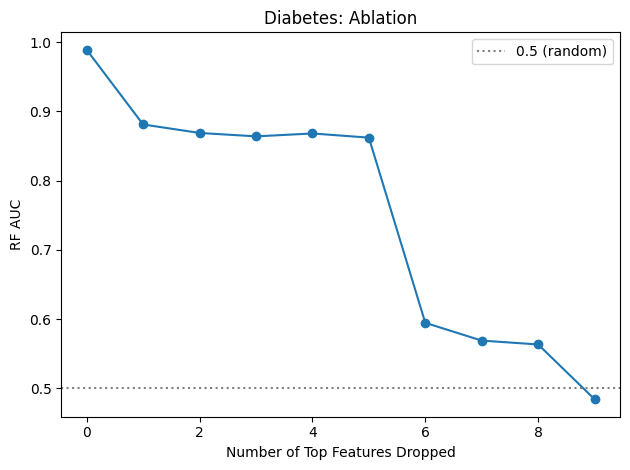

In [17]:
plt.figure()
plt.plot(k_list, auc_l, marker="o")
plt.axhline(0.5, linestyle=":", color="gray", label="0.5 (random)")
plt.xlabel("Number of Top Features Dropped")
plt.ylabel("RF AUC")
plt.title("Diabetes: Ablation")
plt.legend()
plt.tight_layout()
plt.show()


# Distribution of AUC across methods

For each generator, run R=50 stratified train/test splits and record the RF probe AUC. Real and synthetic share the same N=91 (23 neg / 68 pos) to mirror the HIV setup.

In [18]:
import sys
sys.path.insert(0, "..")

from models.bootstrap     import sample_bootstrap
from models.gmm           import sample_gmm
from models.iid_columnwise import sample_columnwise

X_real_arr = X_scaled
y_real_arr = np.asarray(y).astype(int)

n0_target = int((y_real_arr == 0).sum())
n1_target = int((y_real_arr == 1).sum())
print(f"target counts: n0={n0_target}  n1={n1_target}  features={X_real_arr.shape[1]}")


target counts: n0=23  n1=68  features=10


In [19]:
def cvae_sampler(X, y, n0, n1, seed):
    torch.manual_seed(seed)
    Xs0 = sample_scaled(model, n0, y_label=0, device=device)
    Xs1 = sample_scaled(model, n1, y_label=1, device=device)
    Xs  = np.vstack([Xs0, Xs1])
    ys  = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    return Xs, ys

GENERATORS = {
    "bootstrap":  lambda X, y, n0, n1, seed: sample_bootstrap(X, y, n0, n1, seed=seed),
    "gmm":        lambda X, y, n0, n1, seed: sample_gmm(X, y, n0, n1, seed=seed),
    "columnwise": lambda X, y, n0, n1, seed: sample_columnwise(X, y, n0, n1, seed=seed),
    "cvae":       cvae_sampler,
}


In [20]:
R = 50
results = {}

for name, gen in GENERATORS.items():
    aucs = []
    for r in range(R):
        Xs, ys = gen(X_real_arr, y_real_arr, n0_target, n1_target, seed=r)
        auc = one_stochastic_experiment(
            X_real_arr, y_real_arr,
            Xs, ys,
            holdout0=3, holdout1=12,
            train0=20,  train1=20,
            seed=r,
        )
        aucs.append(auc)
    results[name] = np.array(aucs)
    print(f"{name:10s}  mean={results[name].mean():.3f}  std={results[name].std():.3f}")


bootstrap   mean=0.352  std=0.093
gmm         mean=0.922  std=0.062
columnwise  mean=0.596  std=0.106
cvae        mean=0.963  std=0.042


C:\Users\tonyt\AppData\Local\Temp\ipykernel_48072\2324736412.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box, labels=methods, showmeans=True)


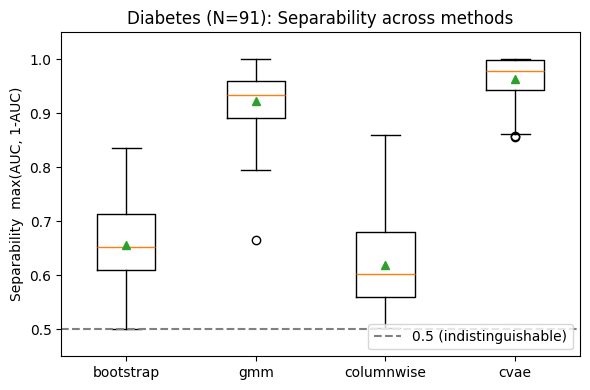

In [21]:
methods = list(results.keys())
data_box = [np.maximum(results[m], 1 - results[m]) for m in methods]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(data_box, labels=methods, showmeans=True)
ax.axhline(0.5, linestyle="--", color="gray", label="0.5 (indistinguishable)")
ax.set_ylim(0.45, 1.05)
ax.set_ylabel("Separability  max(AUC, 1-AUC)")
ax.set_title("Diabetes (N=91): Separability across methods")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("diabetes_method_auc_distribution.png", dpi=300)
plt.show()


# Unrestricted sample size control

The 91-sample subset was chosen to mirror HIV. To rule out sample size as the explanation for the high CVAE distinguishability AUC, we re-run the comparison on the **full** Diabetes dataset, train a fresh CVAE on it, and use a standard 80/20 stratified split (no HIV-shaped capping). If CVAE still sits well above 0.5, sample size is not the cause.

In [22]:
from sklearn.datasets import load_diabetes

data_full = load_diabetes()
X_full = data_full.data
y_full_cont = data_full.target
y_full = (y_full_cont > np.median(y_full_cont)).astype(int)
print("full:", X_full.shape, "class0:", (y_full == 0).sum(), "class1:", (y_full == 1).sum())

scaler_full = StandardScaler().fit(X_full)
X_full_s = scaler_full.transform(X_full)


full: (442, 10) class0: 221 class1: 221


In [23]:
# Train a fresh CVAE on the full dataset
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

X_full_t = torch.tensor(X_full_s, dtype=torch.float32)
y_full_t = torch.tensor(y_full,   dtype=torch.long)

train_loader_full = DataLoader(
    TensorDataset(X_full_t, y_full_t),
    batch_size=cfg.batch_size,
    shuffle=True,
)

model_full = CVAE(x_dim=X_full_s.shape[1], c_dim=2, z_dim=cfg.z_dim, hidden=cfg.hidden).to(device)
opt_full   = torch.optim.Adam(model_full.parameters(), lr=cfg.lr)

for epoch in range(cfg.epochs):
    model_full.train()
    total = 0.0
    for xb, yb in train_loader_full:
        xb = xb.to(device)
        yb = yb.to(device)
        cb = F.one_hot(yb, num_classes=2).float()

        x_hat, mu, logvar = model_full(xb, cb)
        loss = elbo_loss(xb, x_hat, mu, logvar, beta=cfg.beta)

        opt_full.zero_grad()
        loss.backward()
        opt_full.step()
        total += loss.item() * xb.size(0)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | loss={total/len(X_full_t):.4f}")


Epoch  50 | loss=4.9919
Epoch 100 | loss=4.5683
Epoch 150 | loss=4.5090
Epoch 200 | loss=4.4184


In [24]:
def unrestricted_run_auc(X_real, y_real, X_syn, y_syn, seed):
    """Standard 80/20 stratified split on all real+synthetic, RF AUC."""
    X_all = np.vstack([X_real, X_syn])
    s_all = np.r_[np.zeros(len(X_real), dtype=int),
                  np.ones(len(X_syn),  dtype=int)]
    Xtr, Xte, str_, ste = train_test_split(
        X_all, s_all, test_size=0.2, random_state=seed, stratify=s_all
    )
    rf = RandomForestClassifier(n_estimators=500, random_state=seed, n_jobs=-1)
    rf.fit(Xtr, str_)
    p = rf.predict_proba(Xte)[:, 1]
    return roc_auc_score(ste, p)

def cvae_sampler_full(X, y, n0, n1, seed):
    torch.manual_seed(seed)
    Xs0 = sample_scaled(model_full, n0, y_label=0, device=device)
    Xs1 = sample_scaled(model_full, n1, y_label=1, device=device)
    Xs  = np.vstack([Xs0, Xs1])
    ys  = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    return Xs, ys

GENERATORS_FULL = {
    "bootstrap":  lambda X, y, n0, n1, seed: sample_bootstrap(X, y, n0, n1, seed=seed),
    "gmm":        lambda X, y, n0, n1, seed: sample_gmm(X, y, n0, n1, seed=seed),
    "columnwise": lambda X, y, n0, n1, seed: sample_columnwise(X, y, n0, n1, seed=seed),
    "cvae":       cvae_sampler_full,
}

n0_full = int((y_full == 0).sum())
n1_full = int((y_full == 1).sum())
print(f"full N={len(X_full)}  n0={n0_full}  n1={n1_full}")


full N=442  n0=221  n1=221


In [25]:
R = 50
results_full = {}

for name, gen in GENERATORS_FULL.items():
    aucs = []
    for r in range(R):
        Xs, ys = gen(X_full_s, y_full, n0_full, n1_full, seed=r)
        auc = unrestricted_run_auc(X_full_s, y_full, Xs, ys, seed=r)
        aucs.append(auc)
    results_full[name] = np.array(aucs)
    print(f"{name:10s}  mean={results_full[name].mean():.3f}  std={results_full[name].std():.3f}")


bootstrap   mean=0.264  std=0.036
gmm         mean=0.999  std=0.002
columnwise  mean=0.881  std=0.018
cvae        mean=1.000  std=0.001


C:\Users\tonyt\AppData\Local\Temp\ipykernel_48072\1416411974.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box_full, labels=methods_full, showmeans=True)


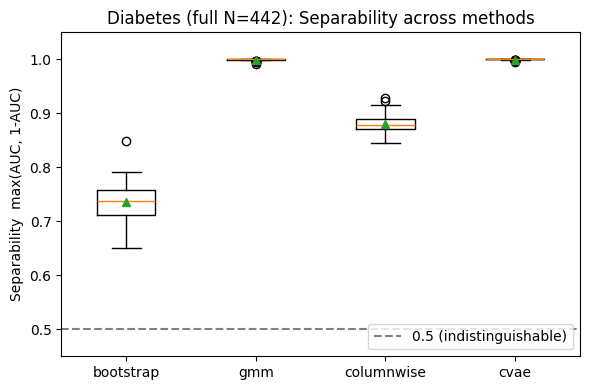

In [26]:
methods_full = list(results_full.keys())
data_box_full = [np.maximum(results_full[m], 1 - results_full[m]) for m in methods_full]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(data_box_full, labels=methods_full, showmeans=True)
ax.axhline(0.5, linestyle="--", color="gray", label="0.5 (indistinguishable)")
ax.set_ylim(0.45, 1.05)
ax.set_ylabel("Separability  max(AUC, 1-AUC)")
ax.set_title("Diabetes (full N=442): Separability across methods")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("diabetes_full_method_auc_distribution.png", dpi=300)
plt.show()
